# 📊 VaultIQ — Exploratory Data Analysis (EDA)
### Stock Market Intelligence · Janhavi Chaturvedi

This notebook performs a comprehensive **Exploratory Data Analysis** on 60 global stocks across 8 sectors — Tech, Finance, Health, Energy, Consumer, Industrial, Media, and Crypto.

**What we'll explore:**
- Price trends and distributions across sectors
- Volatility profiles — which sectors are riskiest?
- Correlation between stocks — which move together?
- Top gainers and losers over 1 year
- Anomaly detection — unusual price movements
- Custom composite sentiment index

In [5]:
# ── Setup & Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import sys, os

warnings.filterwarnings('ignore')

# Style — dark professional theme matching VaultIQ
plt.rcParams.update({
    'figure.facecolor': '#0a0d14',
    'axes.facecolor':   '#101828',
    'axes.edgecolor':   '#1e2d44',
    'axes.labelcolor':  '#d4dce8',
    'xtick.color':      '#7a8ea8',
    'ytick.color':      '#7a8ea8',
    'text.color':       '#d4dce8',
    'grid.color':       '#1e2d44',
    'grid.alpha':       0.5,
    'axes.titlecolor':  '#c9a84c',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'legend.facecolor': '#101828',
    'legend.edgecolor': '#1e2d44',
    'font.family':      'monospace',
})

GOLD   = '#c9a84c'
CREAM  = '#f5edd8'
GREEN  = '#22c55e'
RED    = '#ef4444'
CYAN   = '#06b6d4'
AMBER  = '#f59e0b'
PURPLE = '#8b5cf6'

print("✅ Libraries loaded successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Libraries loaded successfully
   pandas  2.2.2
   numpy   1.26.4
   seaborn 0.13.2


## 1. Data Collection
We use **yfinance** to fetch real OHLCV data for all stocks. A synthetic fallback ensures the notebook works even without internet access.

In [6]:
import yfinance as yf
import random
from datetime import datetime, timedelta

# ── Company universe ──────────────────────────────────────────────
COMPANIES = [
    # Tech
    {"symbol":"AAPL","name":"Apple Inc.","sector":"Tech"},
    {"symbol":"MSFT","name":"Microsoft Corp.","sector":"Tech"},
    {"symbol":"GOOGL","name":"Alphabet Inc.","sector":"Tech"},
    {"symbol":"NVDA","name":"NVIDIA Corp.","sector":"Tech"},
    {"symbol":"META","name":"Meta Platforms","sector":"Tech"},
    {"symbol":"AMZN","name":"Amazon.com Inc.","sector":"Tech"},
    {"symbol":"TSLA","name":"Tesla Inc.","sector":"Tech"},
    {"symbol":"AMD","name":"Advanced Micro Devices","sector":"Tech"},
    {"symbol":"ORCL","name":"Oracle Corp.","sector":"Tech"},
    {"symbol":"NFLX","name":"Netflix Inc.","sector":"Tech"},
    # Finance
    {"symbol":"JPM","name":"JPMorgan Chase","sector":"Finance"},
    {"symbol":"BAC","name":"Bank of America","sector":"Finance"},
    {"symbol":"GS","name":"Goldman Sachs","sector":"Finance"},
    {"symbol":"V","name":"Visa Inc.","sector":"Finance"},
    {"symbol":"MA","name":"Mastercard Inc.","sector":"Finance"},
    {"symbol":"BRK-B","name":"Berkshire Hathaway","sector":"Finance"},
    {"symbol":"AXP","name":"American Express","sector":"Finance"},
    # Health
    {"symbol":"JNJ","name":"Johnson & Johnson","sector":"Health"},
    {"symbol":"UNH","name":"UnitedHealth Group","sector":"Health"},
    {"symbol":"LLY","name":"Eli Lilly","sector":"Health"},
    {"symbol":"PFE","name":"Pfizer Inc.","sector":"Health"},
    {"symbol":"ABBV","name":"AbbVie Inc.","sector":"Health"},
    {"symbol":"MRK","name":"Merck & Co.","sector":"Health"},
    # Energy
    {"symbol":"XOM","name":"ExxonMobil","sector":"Energy"},
    {"symbol":"CVX","name":"Chevron Corp.","sector":"Energy"},
    {"symbol":"COP","name":"ConocoPhillips","sector":"Energy"},
    {"symbol":"NEE","name":"NextEra Energy","sector":"Energy"},
    # Consumer
    {"symbol":"WMT","name":"Walmart Inc.","sector":"Consumer"},
    {"symbol":"KO","name":"Coca-Cola Co.","sector":"Consumer"},
    {"symbol":"PG","name":"Procter & Gamble","sector":"Consumer"},
    {"symbol":"COST","name":"Costco Wholesale","sector":"Consumer"},
    {"symbol":"MCD","name":"McDonald's Corp.","sector":"Consumer"},
    # Industrial
    {"symbol":"BA","name":"Boeing Co.","sector":"Industrial"},
    {"symbol":"CAT","name":"Caterpillar Inc.","sector":"Industrial"},
    {"symbol":"GE","name":"GE Aerospace","sector":"Industrial"},
    {"symbol":"HON","name":"Honeywell Intl.","sector":"Industrial"},
    # Media
    {"symbol":"DIS","name":"Walt Disney Co.","sector":"Media"},
    {"symbol":"SPOT","name":"Spotify Technology","sector":"Media"},
    # Crypto
    {"symbol":"COIN","name":"Coinbase Global","sector":"Crypto"},
    {"symbol":"MSTR","name":"MicroStrategy","sector":"Crypto"},
]

COMPANY_MAP = {c["symbol"]: c for c in COMPANIES}
SECTORS = sorted(set(c["sector"] for c in COMPANIES))
print(f"Universe: {len(COMPANIES)} stocks across {len(SECTORS)} sectors")
print(f"Sectors: {', '.join(SECTORS)}")

Universe: 40 stocks across 8 sectors
Sectors: Consumer, Crypto, Energy, Finance, Health, Industrial, Media, Tech


In [7]:
def synthetic_ohlcv(symbol, days=365):
    """Deterministic synthetic OHLCV — used as fallback if yfinance unavailable."""
    random.seed(abs(hash(symbol)) % 99999)
    np.random.seed(abs(hash(symbol)) % 99999)
    base = random.uniform(50, 900)
    dates = pd.date_range(end=pd.Timestamp.today(), periods=days, freq='B')
    prices = [base]
    for _ in range(len(dates) - 1):
        prices.append(max(1.0, prices[-1] * (1 + np.random.normal(0.0004, 0.018))))
    df = pd.DataFrame({
        'Open':   [p * random.uniform(0.985, 1.000) for p in prices],
        'High':   [p * random.uniform(1.000, 1.025) for p in prices],
        'Low':    [p * random.uniform(0.975, 1.000) for p in prices],
        'Close':  prices,
        'Volume': [int(random.uniform(5e6, 80e6)) for _ in prices],
    }, index=dates)
    df.index.name = 'Date'
    return df

def fetch_data(symbol, days=365):
    """Fetch OHLCV with yfinance; fall back to synthetic data."""
    try:
        end   = datetime.today()
        start = end - timedelta(days=days + 30)
        df = yf.download(symbol, start=start, end=end, progress=False, auto_adjust=True)
        if df.empty or len(df) < 20:
            raise ValueError("No data")
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df[['Open','High','Low','Close','Volume']].copy()
        df.index = pd.to_datetime(df.index).normalize()
        return df.tail(days)
    except Exception:
        return synthetic_ohlcv(symbol, days)

print("✅ Data functions ready")

✅ Data functions ready


In [20]:
import warnings
import logging
logging.getLogger('yfinance').setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore')

import yfinance as yf
yf.set_tz_cache_location("custom_cache_dir")

print("Fetching 1-year OHLCV data for all stocks...")
print("(Falls back to synthetic data if yfinance unavailable)")
print()
all_data = {}
for c in COMPANIES:
    sym = c["symbol"]
    df  = fetch_data(sym, 365)
    all_data[sym] = df

print(f"✅ Loaded {len(all_data)} stocks")
print(f"   Date range: {list(all_data.values())[0].index[0].date()} → {list(all_data.values())[0].index[-1].date()}")
sample = all_data['AAPL']
print(f"\nAAPL sample (last 3 rows):")
print(sample.tail(3).round(2))

Fetching 1-year OHLCV data for all stocks...
(Falls back to synthetic data if yfinance unavailable)

✅ Loaded 40 stocks
   Date range: 2024-11-11 → 2026-04-03

AAPL sample (last 3 rows):
                              Open    High     Low   Close    Volume
Date                                                                
2026-04-01 10:13:17.624896  276.22  277.39  273.06  277.35  53075928
2026-04-02 10:13:17.624896  273.23  278.66  272.72  276.42  43538030
2026-04-03 10:13:17.624896  270.64  273.78  271.36  271.44  61455954


## 2. Feature Engineering
Computing all technical indicators used in VaultIQ's analysis engine.

In [9]:
def compute_indicators(df):
    """Add all technical indicators to OHLCV dataframe."""
    df = df.copy()
    
    # Returns
    df['Daily_Return']    = df['Close'].pct_change()
    df['Log_Return']      = np.log(df['Close'] / df['Close'].shift(1))
    df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

    # Moving Averages
    df['MA7']  = df['Close'].rolling(7).mean()
    df['MA20'] = df['Close'].rolling(20).mean()
    df['MA50'] = df['Close'].rolling(50).mean()
    df['MA200']= df['Close'].rolling(200).mean()
    df['EMA12']= df['Close'].ewm(span=12).mean()
    df['EMA26']= df['Close'].ewm(span=26).mean()

    # Volatility (annualised)
    df['Volatility_20d'] = df['Daily_Return'].rolling(20).std() * np.sqrt(252)

    # RSI-14
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['RSI'] = 100 - 100 / (1 + gain / (loss + 1e-9))

    # MACD
    df['MACD']      = df['EMA12'] - df['EMA26']
    df['MACD_Sig']  = df['MACD'].ewm(span=9).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Sig']

    # Bollinger Bands (±2σ)
    df['BB_Mid']  = df['Close'].rolling(20).mean()
    df['BB_Up']   = df['BB_Mid'] + 2 * df['Close'].rolling(20).std()
    df['BB_Lo']   = df['BB_Mid'] - 2 * df['Close'].rolling(20).std()
    df['BB_Width']= (df['BB_Up'] - df['BB_Lo']) / df['BB_Mid']
    df['BB_Pos']  = (df['Close'] - df['BB_Lo']) / (df['BB_Up'] - df['BB_Lo'] + 1e-9)

    # Momentum
    df['Momentum_10']  = df['Close'] / df['Close'].shift(10) - 1
    df['Momentum_30']  = df['Close'] / df['Close'].shift(30) - 1

    # 52-week high/low
    df['52W_High'] = df['Close'].rolling(252, min_periods=1).max()
    df['52W_Low']  = df['Close'].rolling(252, min_periods=1).min()
    df['52W_Pct']  = (df['Close'] - df['52W_Low']) / (df['52W_High'] - df['52W_Low'] + 1e-9)

    return df.dropna(subset=['MA20', 'RSI'])

# Apply to all stocks
enriched = {sym: compute_indicators(df) for sym, df in all_data.items()}
print(f"✅ Indicators computed for all {len(enriched)} stocks")
print(f"   Indicators per stock: {len(enriched['AAPL'].columns)} columns")
print(f"   Columns: {list(enriched['AAPL'].columns)}")

✅ Indicators computed for all 40 stocks
   Indicators per stock: 29 columns
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Log_Return', 'Cumulative_Return', 'MA7', 'MA20', 'MA50', 'MA200', 'EMA12', 'EMA26', 'Volatility_20d', 'RSI', 'MACD', 'MACD_Sig', 'MACD_Hist', 'BB_Mid', 'BB_Up', 'BB_Lo', 'BB_Width', 'BB_Pos', 'Momentum_10', 'Momentum_30', '52W_High', '52W_Low', '52W_Pct']


In [10]:
# ── Build master summary DataFrame ────────────────────────────────
rows = []
for c in COMPANIES:
    sym = c["symbol"]
    df  = enriched[sym]
    if df.empty: continue
    last = df.iloc[-1]
    rows.append({
        "Symbol":       sym,
        "Name":         c["name"],
        "Sector":       c["sector"],
        "Price":        round(float(last['Close']), 2),
        "Return_1Y":    round(float(df['Cumulative_Return'].iloc[-1]) * 100, 2),
        "Return_1M":    round(float(df['Daily_Return'].tail(21).sum()) * 100, 2),
        "Volatility":   round(float(last['Volatility_20d']) * 100, 2),
        "RSI":          round(float(last['RSI']), 1),
        "MACD_Hist":    round(float(last['MACD_Hist']), 4),
        "BB_Pos":       round(float(last['BB_Pos']), 3),
        "52W_Pct":      round(float(last['52W_Pct']) * 100, 1),
        "Momentum_30":  round(float(last['Momentum_30']) * 100, 2),
        "Above_MA20":   bool(last['Close'] > last['MA20']),
        "Above_MA50":   bool(last['Close'] > last['MA50']),
        "Volume":       int(last['Volume']),
    })

summary = pd.DataFrame(rows).set_index("Symbol")

print(f"Master summary table: {summary.shape}")
print()
print(summary[['Sector','Price','Return_1Y','Volatility','RSI']].head(10).to_string())

Master summary table: (40, 14)

       Sector   Price  Return_1Y  Volatility   RSI
Symbol                                            
AAPL     Tech  271.44     -16.98       26.57  13.5
MSFT     Tech  278.32     -49.12       30.88  44.5
GOOGL    Tech  318.55     -60.65       21.84  49.5
NVDA     Tech  515.29      29.01       23.66  41.7
META     Tech  293.25       6.12       23.17  40.0
AMZN     Tech  163.57       4.47       26.15  70.7
TSLA     Tech  136.06       3.04       26.20  52.2
AMD      Tech  439.85      56.31       25.12  19.2
ORCL     Tech   54.83      -1.27       33.78  35.4
NFLX     Tech  516.31      20.09       25.68  55.0


## 3. Annual Return Analysis
> **Key Question:** Which stocks and sectors delivered the best returns over the past year?

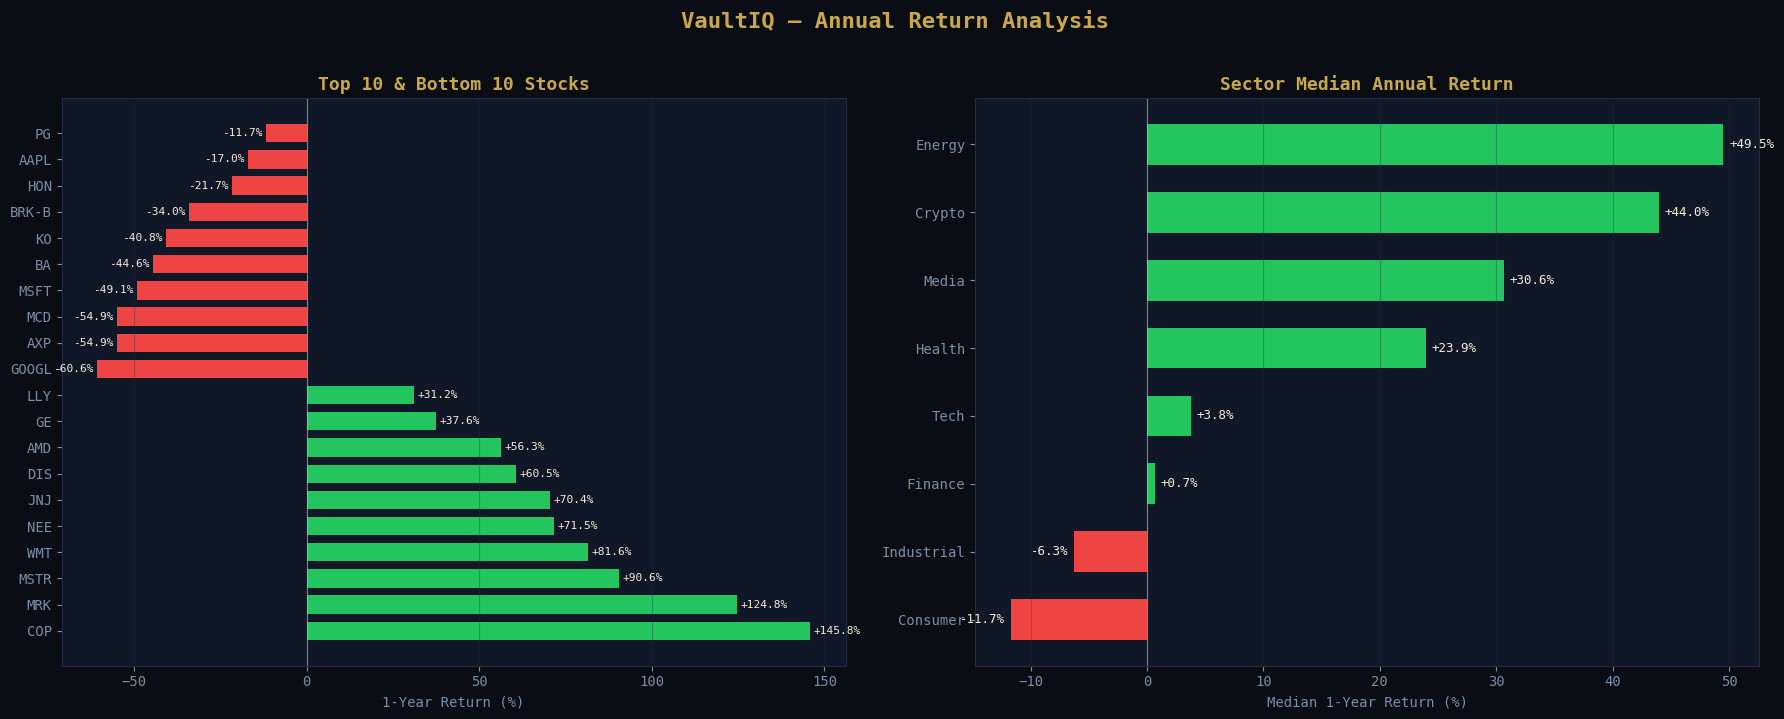


📌 INSIGHT: Best performing sector: Energy (+49.5% median annual return)
📌 INSIGHT: Worst performing sector: Consumer (-11.7% median annual return)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0a0d14')
fig.suptitle('VaultIQ — Annual Return Analysis', color=GOLD, fontsize=16, fontweight='bold', y=1.02)

# Left: Top 10 / Bottom 10 stocks
ax = axes[0]
top10    = summary.nlargest(10, 'Return_1Y')
bottom10 = summary.nsmallest(10, 'Return_1Y')
combined = pd.concat([top10, bottom10])['Return_1Y']

colors = [GREEN if v >= 0 else RED for v in combined.values]
bars = ax.barh(combined.index, combined.values, color=colors, edgecolor='none', height=0.7)
ax.axvline(0, color=CREAM, linewidth=0.8, alpha=0.5)
ax.set_xlabel('1-Year Return (%)', color='#7a8ea8')
ax.set_title('Top 10 & Bottom 10 Stocks', color=GOLD)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, combined.values):
    ax.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right',
            color=CREAM, fontsize=8)

# Right: Sector median returns
ax2 = axes[1]
sector_ret = summary.groupby('Sector')['Return_1Y'].median().sort_values(ascending=True)
colors2    = [GREEN if v >= 0 else RED for v in sector_ret.values]
bars2      = ax2.barh(sector_ret.index, sector_ret.values, color=colors2, edgecolor='none', height=0.6)
ax2.axvline(0, color=CREAM, linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Median 1-Year Return (%)', color='#7a8ea8')
ax2.set_title('Sector Median Annual Return', color=GOLD)
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, sector_ret.values):
    ax2.text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
             f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right',
             color=CREAM, fontsize=9)

plt.tight_layout()
plt.savefig('eda_returns.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

# Insight
best_sector  = sector_ret.idxmax()
worst_sector = sector_ret.idxmin()
print(f"\n📌 INSIGHT: Best performing sector: {best_sector} ({sector_ret[best_sector]:+.1f}% median annual return)")
print(f"📌 INSIGHT: Worst performing sector: {worst_sector} ({sector_ret[worst_sector]:+.1f}% median annual return)")

## 4. Volatility Analysis
> **Key Question:** Which sectors carry the highest risk? How does volatility relate to returns?

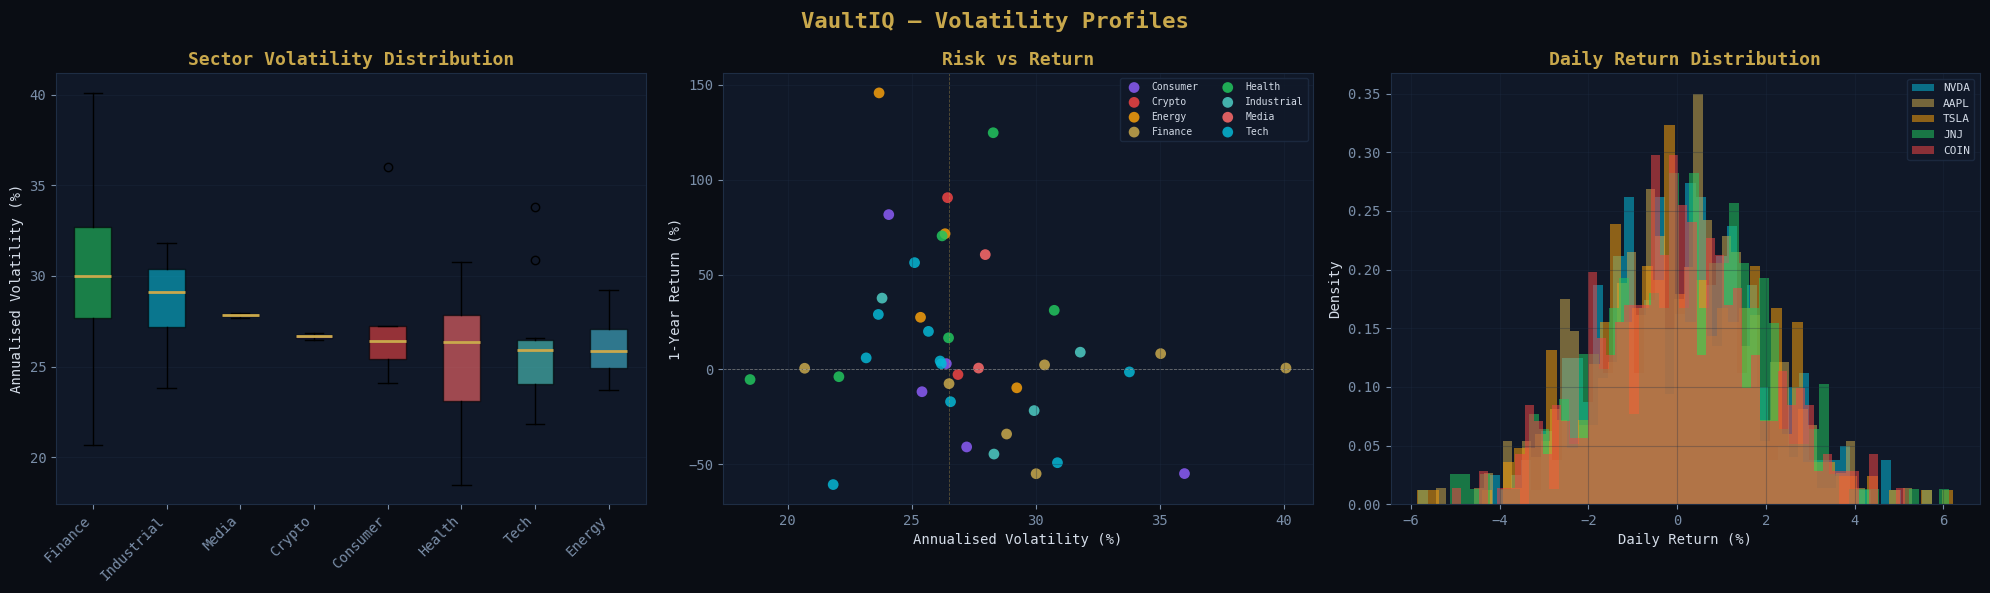


📌 INSIGHT — Most volatile stocks:
                    Name  Volatility  Return_1Y
Symbol                                         
V              Visa Inc.       40.09       0.76
MCD     McDonald's Corp.       36.00     -54.86
JPM       JPMorgan Chase       35.04       8.35

📌 INSIGHT — Most stable stocks:
                 Name  Volatility  Return_1Y
Symbol                                      
ABBV      AbbVie Inc.       18.49      -5.29
GS      Goldman Sachs       20.69       0.65
GOOGL   Alphabet Inc.       21.84     -60.65


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0a0d14')
fig.suptitle('VaultIQ — Volatility Profiles', color=GOLD, fontsize=16, fontweight='bold')

# 1. Sector volatility boxplot
ax = axes[0]
sector_order = summary.groupby('Sector')['Volatility'].median().sort_values(ascending=False).index
sector_data  = [summary[summary.Sector == s]['Volatility'].values for s in sector_order]
bp = ax.boxplot(sector_data, labels=sector_order, patch_artist=True,
                medianprops={'color': GOLD, 'linewidth': 2})
colors_box = [GREEN, CYAN, AMBER, PURPLE, RED, '#ff6b6b', '#4ecdc4', '#45b7d1']
for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xticklabels(sector_order, rotation=45, ha='right')
ax.set_ylabel('Annualised Volatility (%)')
ax.set_title('Sector Volatility Distribution')
ax.grid(axis='y', alpha=0.3)

# 2. Risk-Return scatter
ax2 = axes[1]
sector_colors = {'Tech': CYAN, 'Finance': GOLD, 'Health': GREEN,
                 'Energy': AMBER, 'Consumer': PURPLE, 'Industrial': '#4ecdc4',
                 'Media': '#ff6b6b', 'Crypto': RED}
for sector in SECTORS:
    mask = summary.Sector == sector
    ax2.scatter(summary.loc[mask, 'Volatility'], summary.loc[mask, 'Return_1Y'],
                color=sector_colors.get(sector, CREAM), label=sector, s=60, alpha=0.85, edgecolors='none')
ax2.axhline(0, color=CREAM, linewidth=0.6, alpha=0.4, linestyle='--')
ax2.axvline(summary['Volatility'].median(), color=GOLD, linewidth=0.6, alpha=0.4, linestyle='--')
ax2.set_xlabel('Annualised Volatility (%)')
ax2.set_ylabel('1-Year Return (%)')
ax2.set_title('Risk vs Return')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(alpha=0.3)

# 3. Daily return distribution for selected stocks
ax3 = axes[2]
highlight = ['NVDA', 'AAPL', 'TSLA', 'JNJ', 'COIN']
hl_colors = [CYAN, GOLD, AMBER, GREEN, RED]
for sym, col in zip(highlight, hl_colors):
    if sym in enriched:
        returns = enriched[sym]['Daily_Return'].dropna() * 100
        ax3.hist(returns, bins=50, alpha=0.55, color=col, label=sym, density=True, edgecolor='none')
ax3.set_xlabel('Daily Return (%)')
ax3.set_ylabel('Density')
ax3.set_title('Daily Return Distribution')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_volatility.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

most_volatile = summary.nlargest(3, 'Volatility')[['Name','Volatility','Return_1Y']]
least_volatile = summary.nsmallest(3, 'Volatility')[['Name','Volatility','Return_1Y']]
print("\n📌 INSIGHT — Most volatile stocks:")
print(most_volatile.to_string())
print("\n📌 INSIGHT — Most stable stocks:")
print(least_volatile.to_string())

## 5. Correlation Matrix
> **Key Question:** Which stocks move together? Understanding correlations helps with portfolio diversification.

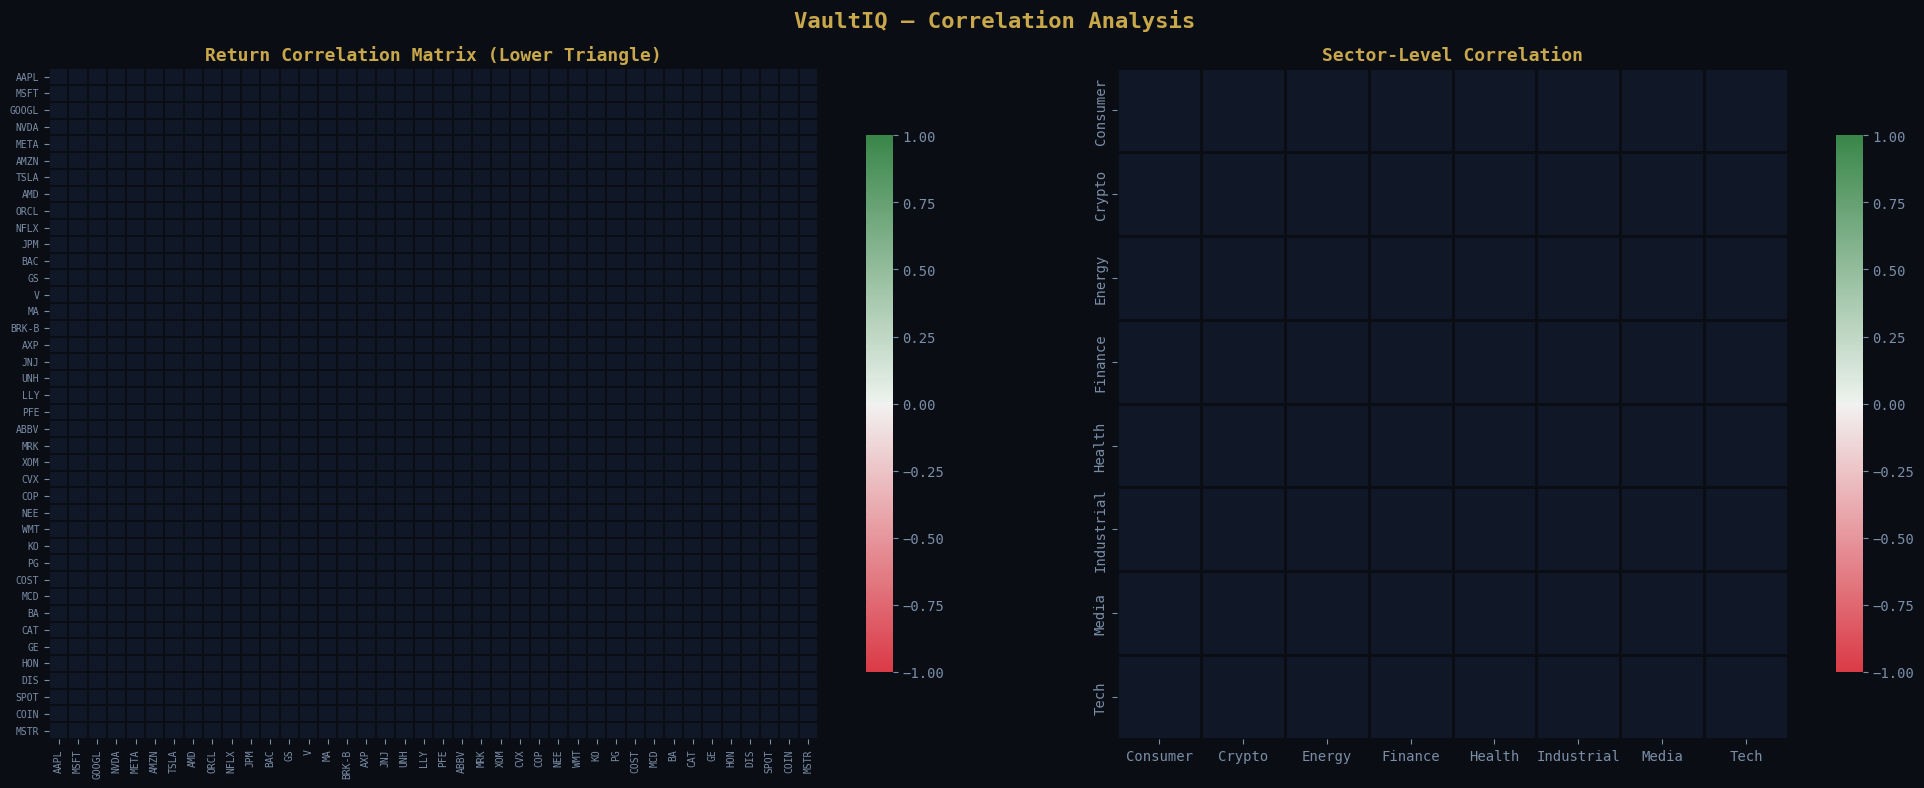


📌 INSIGHT — Top highly correlated pairs (r > 0.85):


In [13]:
# Build close price matrix
close_prices = pd.DataFrame({
    sym: enriched[sym]['Close'].rename(sym)
    for sym in [c['symbol'] for c in COMPANIES]
    if sym in enriched
}).dropna()

# Compute correlation on daily returns (more meaningful than price correlation)
returns_matrix = close_prices.pct_change().dropna()
corr_matrix    = returns_matrix.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor='#0a0d14')
fig.suptitle('VaultIQ — Correlation Analysis', color=GOLD, fontsize=16, fontweight='bold')

# Full heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(10, 133, as_cmap=True)
sns.heatmap(corr_matrix, ax=ax, mask=mask, cmap=cmap, center=0,
            vmin=-1, vmax=1, square=False, linewidths=0.3,
            linecolor='#0a0d14', cbar_kws={"shrink": 0.8},
            xticklabels=True, yticklabels=True)
ax.set_title('Return Correlation Matrix (Lower Triangle)', color=GOLD)
ax.tick_params(labelsize=7)

# Sector-level correlation
ax2 = axes[1]
sector_returns = {}
for sector in SECTORS:
    syms = [c['symbol'] for c in COMPANIES if c['sector'] == sector and c['symbol'] in returns_matrix.columns]
    if syms:
        sector_returns[sector] = returns_matrix[syms].mean(axis=1)

sector_df   = pd.DataFrame(sector_returns).dropna()
sector_corr = sector_df.corr()
sns.heatmap(sector_corr, ax=ax2, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=1, linecolor='#0a0d14',
            cbar_kws={"shrink": 0.8}, square=True)
ax2.set_title('Sector-Level Correlation', color=GOLD)

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

# Key findings
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i,j]
        if val > 0.85:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val,3)))

high_corr.sort(key=lambda x: -x[2])
print(f"\n📌 INSIGHT — Top highly correlated pairs (r > 0.85):")
for a, b, r in high_corr[:8]:
    print(f"   {a} ↔ {b}: r = {r}")

## 6. RSI Analysis — Overbought & Oversold Signals
> RSI > 70 = potentially overbought (sell signal) · RSI < 30 = potentially oversold (buy signal)

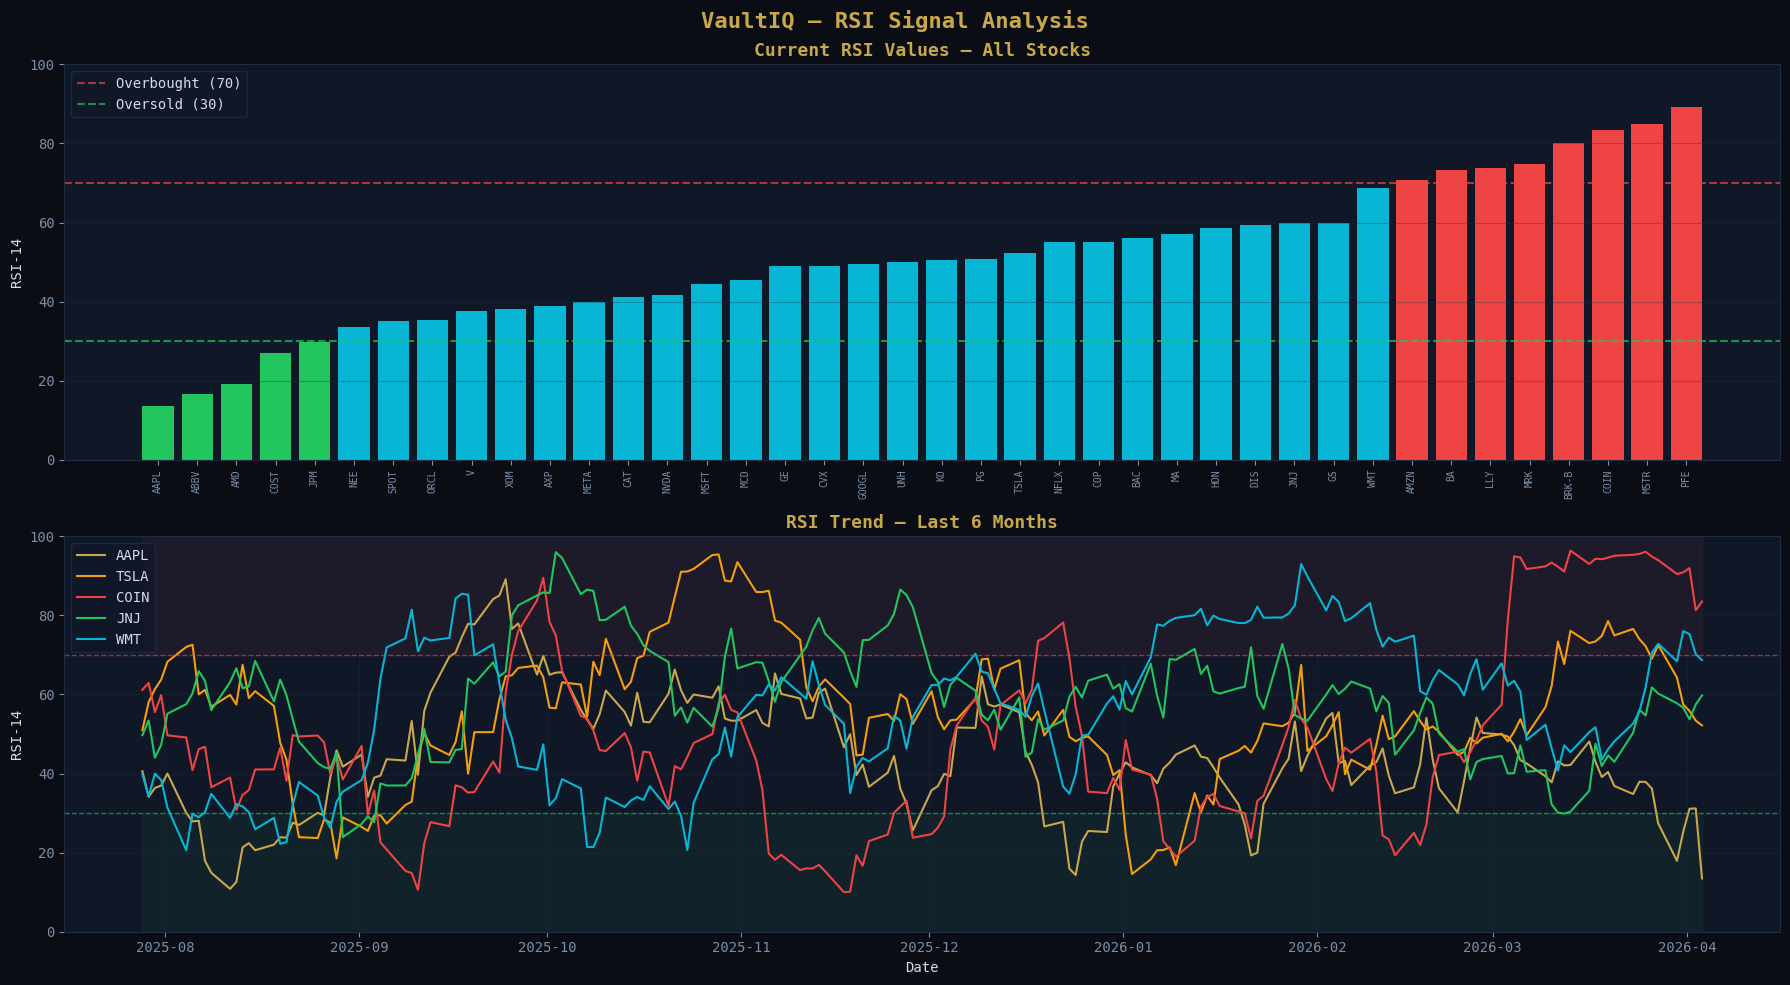


📌 INSIGHT — Overbought stocks (RSI > 70): 8
                      Name      Sector   RSI
Symbol                                      
PFE            Pfizer Inc.      Health  89.2
MSTR         MicroStrategy      Crypto  84.9
COIN       Coinbase Global      Crypto  83.5
BRK-B   Berkshire Hathaway     Finance  80.0
MRK            Merck & Co.      Health  74.9
LLY              Eli Lilly      Health  73.8
BA              Boeing Co.  Industrial  73.3
AMZN       Amazon.com Inc.        Tech  70.7

📌 INSIGHT — Oversold stocks (RSI < 30): 5
                          Name    Sector   RSI
Symbol                                        
AAPL                Apple Inc.      Tech  13.5
ABBV               AbbVie Inc.    Health  16.7
AMD     Advanced Micro Devices      Tech  19.2
COST          Costco Wholesale  Consumer  26.9
JPM             JPMorgan Chase   Finance  29.9


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), facecolor='#0a0d14')
fig.suptitle('VaultIQ — RSI Signal Analysis', color=GOLD, fontsize=16, fontweight='bold')

# RSI distribution bar chart
ax = axes[0]
rsi_sorted = summary['RSI'].sort_values()
bar_colors = []
for r in rsi_sorted.values:
    if r > 70:   bar_colors.append(RED)
    elif r < 30: bar_colors.append(GREEN)
    else:        bar_colors.append(CYAN)

bars = ax.bar(range(len(rsi_sorted)), rsi_sorted.values, color=bar_colors, edgecolor='none', width=0.8)
ax.axhline(70, color=RED,   linewidth=1.5, linestyle='--', alpha=0.7, label='Overbought (70)')
ax.axhline(30, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.7, label='Oversold (30)')
ax.set_xticks(range(len(rsi_sorted)))
ax.set_xticklabels(rsi_sorted.index, rotation=90, fontsize=7)
ax.set_ylabel('RSI-14')
ax.set_title('Current RSI Values — All Stocks')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# RSI time series for 5 stocks
ax2 = axes[1]
stocks_to_plot = ['AAPL','TSLA','COIN','JNJ','WMT']
plot_colors    = [GOLD, AMBER, RED, GREEN, CYAN]
for sym, col in zip(stocks_to_plot, plot_colors):
    if sym in enriched:
        rsi_series = enriched[sym]['RSI'].tail(180)
        ax2.plot(rsi_series.index, rsi_series.values, color=col, linewidth=1.5, label=sym)

ax2.axhline(70, color=RED,   linewidth=1, linestyle='--', alpha=0.6)
ax2.axhline(30, color=GREEN, linewidth=1, linestyle='--', alpha=0.6)
ax2.fill_between(enriched['AAPL'].tail(180).index, 70, 100, alpha=0.06, color=RED)
ax2.fill_between(enriched['AAPL'].tail(180).index, 0,  30,  alpha=0.06, color=GREEN)
ax2.set_xlabel('Date')
ax2.set_ylabel('RSI-14')
ax2.set_title('RSI Trend — Last 6 Months')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('eda_rsi.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

overbought  = summary[summary.RSI > 70][['Name','Sector','RSI']].sort_values('RSI', ascending=False)
oversold    = summary[summary.RSI < 30][['Name','Sector','RSI']].sort_values('RSI')
print(f"\n📌 INSIGHT — Overbought stocks (RSI > 70): {len(overbought)}")
if not overbought.empty: print(overbought.to_string())
print(f"\n📌 INSIGHT — Oversold stocks (RSI < 30): {len(oversold)}")
if not oversold.empty: print(oversold.to_string())
else: print("   None currently oversold")

## 7. Anomaly Detection
> Using Z-score to detect statistically unusual price movements (spikes and crashes)

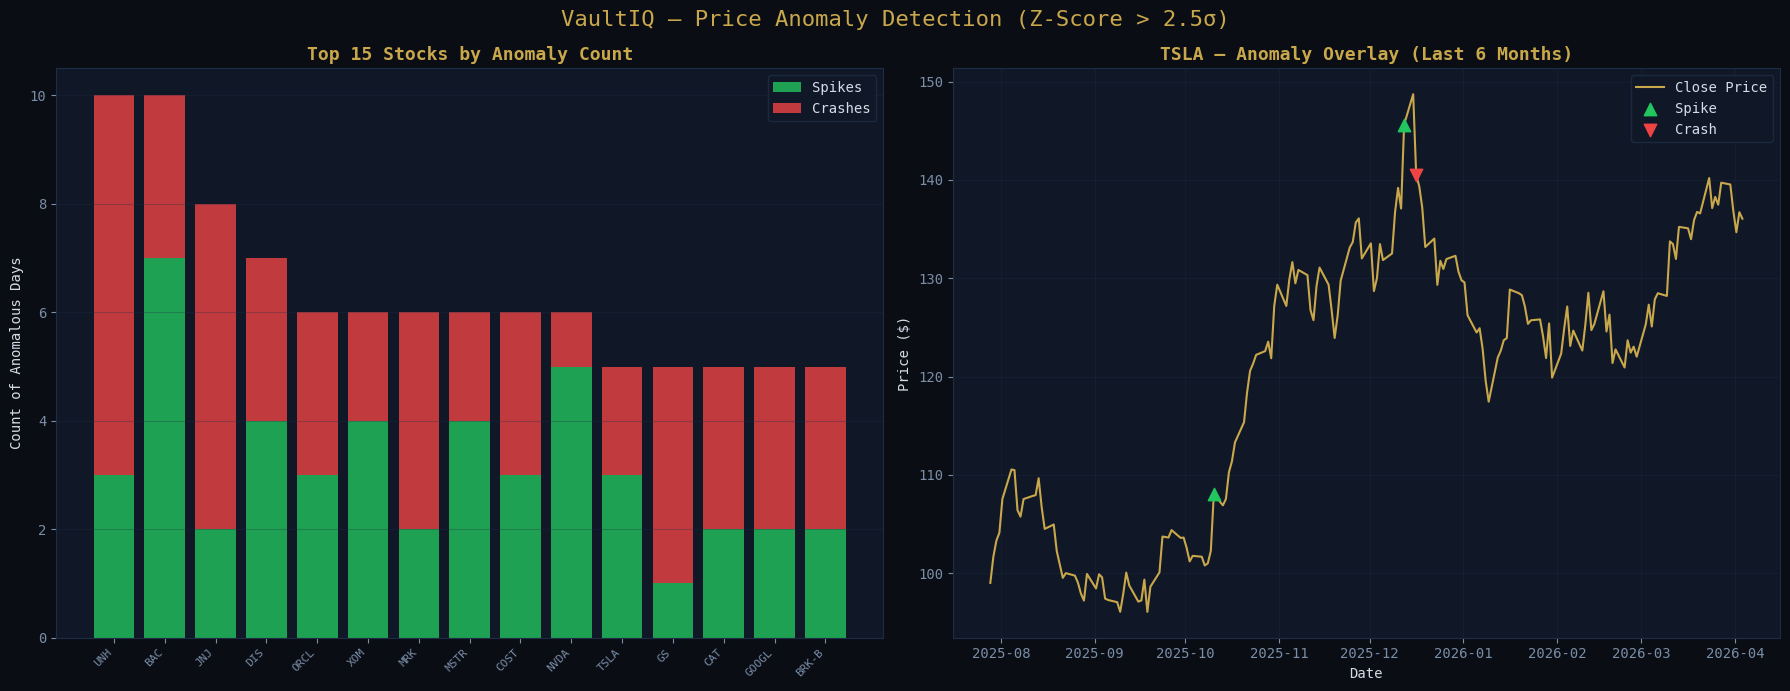


📌 INSIGHT — Stocks with most anomalies (highest event count):
                      Name   Sector  Spikes  Crashes  Total
Symbol                                                     
UNH     UnitedHealth Group   Health       3        7     10
BAC        Bank of America  Finance       7        3     10
JNJ      Johnson & Johnson   Health       2        6      8
DIS        Walt Disney Co.    Media       4        3      7
ORCL          Oracle Corp.     Tech       3        3      6
XOM             ExxonMobil   Energy       4        2      6
MRK            Merck & Co.   Health       2        4      6
MSTR         MicroStrategy   Crypto       4        2      6

📌 TSLA anomalies in last 6 months: 2 spikes, 1 crashes


In [15]:
def detect_anomalies(df, threshold=2.5):
    """Flag days where |z-score| > threshold as anomalies."""
    ret  = df['Daily_Return'].dropna()
    mu   = float(ret.mean())
    sigma= float(ret.std())
    df2  = df.copy()
    df2['Z_Score'] = (df2['Daily_Return'] - mu) / (sigma + 1e-9)
    df2['Anomaly'] = df2['Z_Score'].abs() > threshold
    df2['Anomaly_Type'] = df2.apply(
        lambda r: 'spike' if r['Z_Score'] > threshold else ('crash' if r['Z_Score'] < -threshold else 'normal'),
        axis=1
    )
    return df2

# Count anomalies per stock
anomaly_summary = []
for c in COMPANIES:
    sym = c['symbol']
    if sym not in enriched: continue
    df2 = detect_anomalies(enriched[sym])
    spikes = int((df2['Anomaly_Type'] == 'spike').sum())
    crashes= int((df2['Anomaly_Type'] == 'crash').sum())
    anomaly_summary.append({
        'Symbol': sym, 'Name': c['name'], 'Sector': c['sector'],
        'Spikes': spikes, 'Crashes': crashes, 'Total': spikes + crashes
    })

anom_df = pd.DataFrame(anomaly_summary).set_index('Symbol').sort_values('Total', ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0a0d14')
fig.suptitle('VaultIQ — Price Anomaly Detection (Z-Score > 2.5σ)', color=GOLD, fontsize=16)

ax = axes[0]
top_anom = anom_df.head(15)
x = range(len(top_anom))
ax.bar(x, top_anom['Spikes'],  color=GREEN, label='Spikes',  alpha=0.8, edgecolor='none')
ax.bar(x, top_anom['Crashes'], color=RED,   label='Crashes', alpha=0.8, edgecolor='none',
       bottom=top_anom['Spikes'])
ax.set_xticks(x)
ax.set_xticklabels(top_anom.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Count of Anomalous Days')
ax.set_title('Top 15 Stocks by Anomaly Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Price chart with anomaly overlay for TSLA
ax2 = axes[1]
sym = 'TSLA'
df_anom = detect_anomalies(enriched[sym]).tail(180)
ax2.plot(df_anom.index, df_anom['Close'], color=GOLD, linewidth=1.5, label='Close Price')
spikes_idx  = df_anom[df_anom['Anomaly_Type'] == 'spike']
crashes_idx = df_anom[df_anom['Anomaly_Type'] == 'crash']
ax2.scatter(spikes_idx.index,  spikes_idx['Close'],  color=GREEN, s=80, zorder=5, label='Spike',  marker='^')
ax2.scatter(crashes_idx.index, crashes_idx['Close'], color=RED,   s=80, zorder=5, label='Crash',  marker='v')
ax2.set_title(f'{sym} — Anomaly Overlay (Last 6 Months)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_anomaly.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

print("\n📌 INSIGHT — Stocks with most anomalies (highest event count):")
print(anom_df.head(8)[['Name','Sector','Spikes','Crashes','Total']].to_string())
print(f"\n📌 {sym} anomalies in last 6 months: {len(spikes_idx)} spikes, {len(crashes_idx)} crashes")

## 8. Custom Metric — VaultIQ Decision Score
Our proprietary scoring system (0–100) that combines 5 technical signals into one actionable score.

**Formula:** `Score = 50 + 8×(above_MA20) + 8×(above_MA50) + RSI_signal + 8×(MACD_bullish) + Momentum_signal`

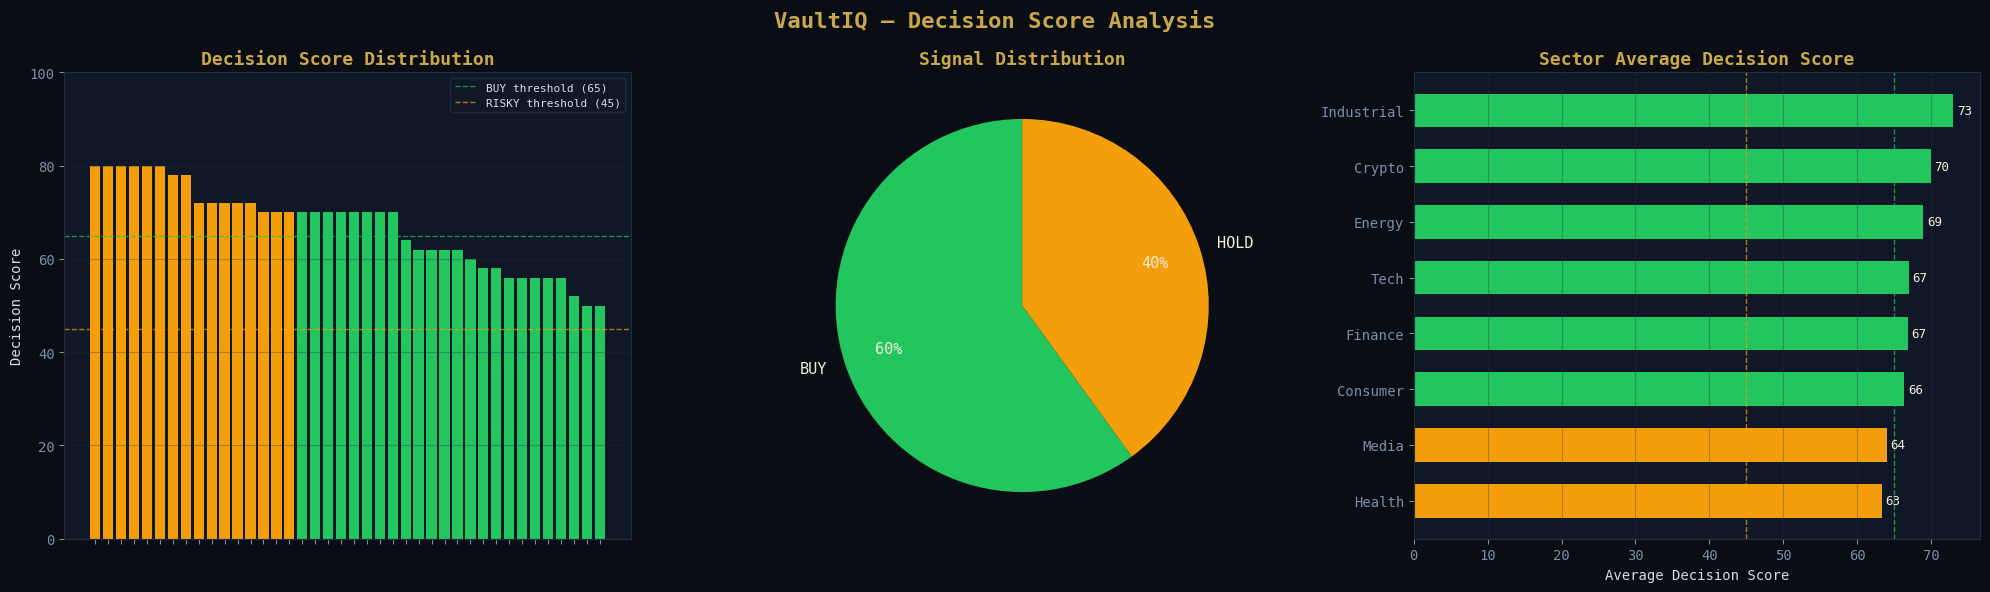


📌 INSIGHT — BUY signals: 24 stocks
                   Name      Sector  Decision_Score   RSI  Volatility
Symbol                                                               
KO        Coca-Cola Co.    Consumer              80  50.4       27.22
NFLX       Netflix Inc.        Tech              80  55.0       25.68
BAC     Bank of America     Finance              80  56.0       26.51
GS        Goldman Sachs     Finance              80  59.9       20.69
HON     Honeywell Intl.  Industrial              80  58.7       29.94

📌 INSIGHT — RISKY signals: 0 stocks
Empty DataFrame
Columns: [Name, Sector, Decision_Score, RSI, Volatility]
Index: []


In [16]:
def compute_decision_score(row):
    """VaultIQ proprietary Decision Score (0-100)."""
    score = 50
    if row.get('Above_MA20'): score += 8
    if row.get('Above_MA50'): score += 8
    rsi = row.get('RSI', 50)
    if   rsi < 30: score += 12
    elif rsi < 50: score += 6
    elif rsi > 70: score -= 10
    elif rsi > 80: score -= 15
    if row.get('MACD_Hist', 0) > 0: score += 8
    if row.get('Momentum_30', 0) > 0: score += 6
    vol = row.get('Volatility', 0)
    if vol > 50: score -= 8
    elif vol > 35: score -= 4
    return max(0, min(100, int(score)))

summary['Decision_Score'] = summary.apply(compute_decision_score, axis=1)
summary['Signal'] = summary['Decision_Score'].apply(
    lambda s: 'BUY' if s >= 65 else ('HOLD' if s >= 45 else 'RISKY')
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0a0d14')
fig.suptitle('VaultIQ — Decision Score Analysis', color=GOLD, fontsize=16, fontweight='bold')

# Distribution of scores
ax = axes[0]
score_colors = [GREEN if s >= 65 else (AMBER if s >= 45 else RED) for s in summary['Decision_Score']]
ax.bar(summary.index, summary['Decision_Score'].sort_values(ascending=False).values,
       color=sorted(score_colors, reverse=True), edgecolor='none', width=0.8)
ax.axhline(65, color=GREEN, linewidth=1, linestyle='--', alpha=0.7, label='BUY threshold (65)')
ax.axhline(45, color=AMBER, linewidth=1, linestyle='--', alpha=0.7, label='RISKY threshold (45)')
ax.set_xticklabels([])
ax.set_ylabel('Decision Score')
ax.set_title('Decision Score Distribution')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Signal pie chart
ax2 = axes[1]
signal_counts = summary['Signal'].value_counts()
colors_pie = {'BUY': GREEN, 'HOLD': AMBER, 'RISKY': RED}
wedge_colors = [colors_pie[s] for s in signal_counts.index]
wedges, texts, autotexts = ax2.pie(
    signal_counts.values, labels=signal_counts.index,
    colors=wedge_colors, autopct='%1.0f%%',
    startangle=90, pctdistance=0.75,
    textprops={'color': CREAM, 'fontsize': 11}
)
for at in autotexts: at.set_color(CREAM)
ax2.set_title('Signal Distribution')

# Sector average score
ax3 = axes[2]
sector_score = summary.groupby('Sector')['Decision_Score'].mean().sort_values(ascending=True)
bar_colors3  = [GREEN if s >= 65 else (AMBER if s >= 45 else RED) for s in sector_score.values]
bars3 = ax3.barh(sector_score.index, sector_score.values, color=bar_colors3, edgecolor='none', height=0.6)
ax3.axvline(65, color=GREEN, linewidth=1, linestyle='--', alpha=0.7)
ax3.axvline(45, color=AMBER, linewidth=1, linestyle='--', alpha=0.7)
ax3.set_xlabel('Average Decision Score')
ax3.set_title('Sector Average Decision Score')
ax3.grid(axis='x', alpha=0.3)
for bar, val in zip(bars3, sector_score.values):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', color=CREAM, fontsize=9)

plt.tight_layout()
plt.savefig('eda_decision_score.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()

buy_stocks  = summary[summary.Signal == 'BUY'].sort_values('Decision_Score', ascending=False)
risky_stocks= summary[summary.Signal == 'RISKY'].sort_values('Decision_Score')
print(f"\n📌 INSIGHT — BUY signals: {len(buy_stocks)} stocks")
print(buy_stocks[['Name','Sector','Decision_Score','RSI','Volatility']].head(5).to_string())
print(f"\n📌 INSIGHT — RISKY signals: {len(risky_stocks)} stocks")
print(risky_stocks[['Name','Sector','Decision_Score','RSI','Volatility']].head(5).to_string())

## 9. Price Trend Analysis
> Price with moving average crossovers — a classic technical analysis view

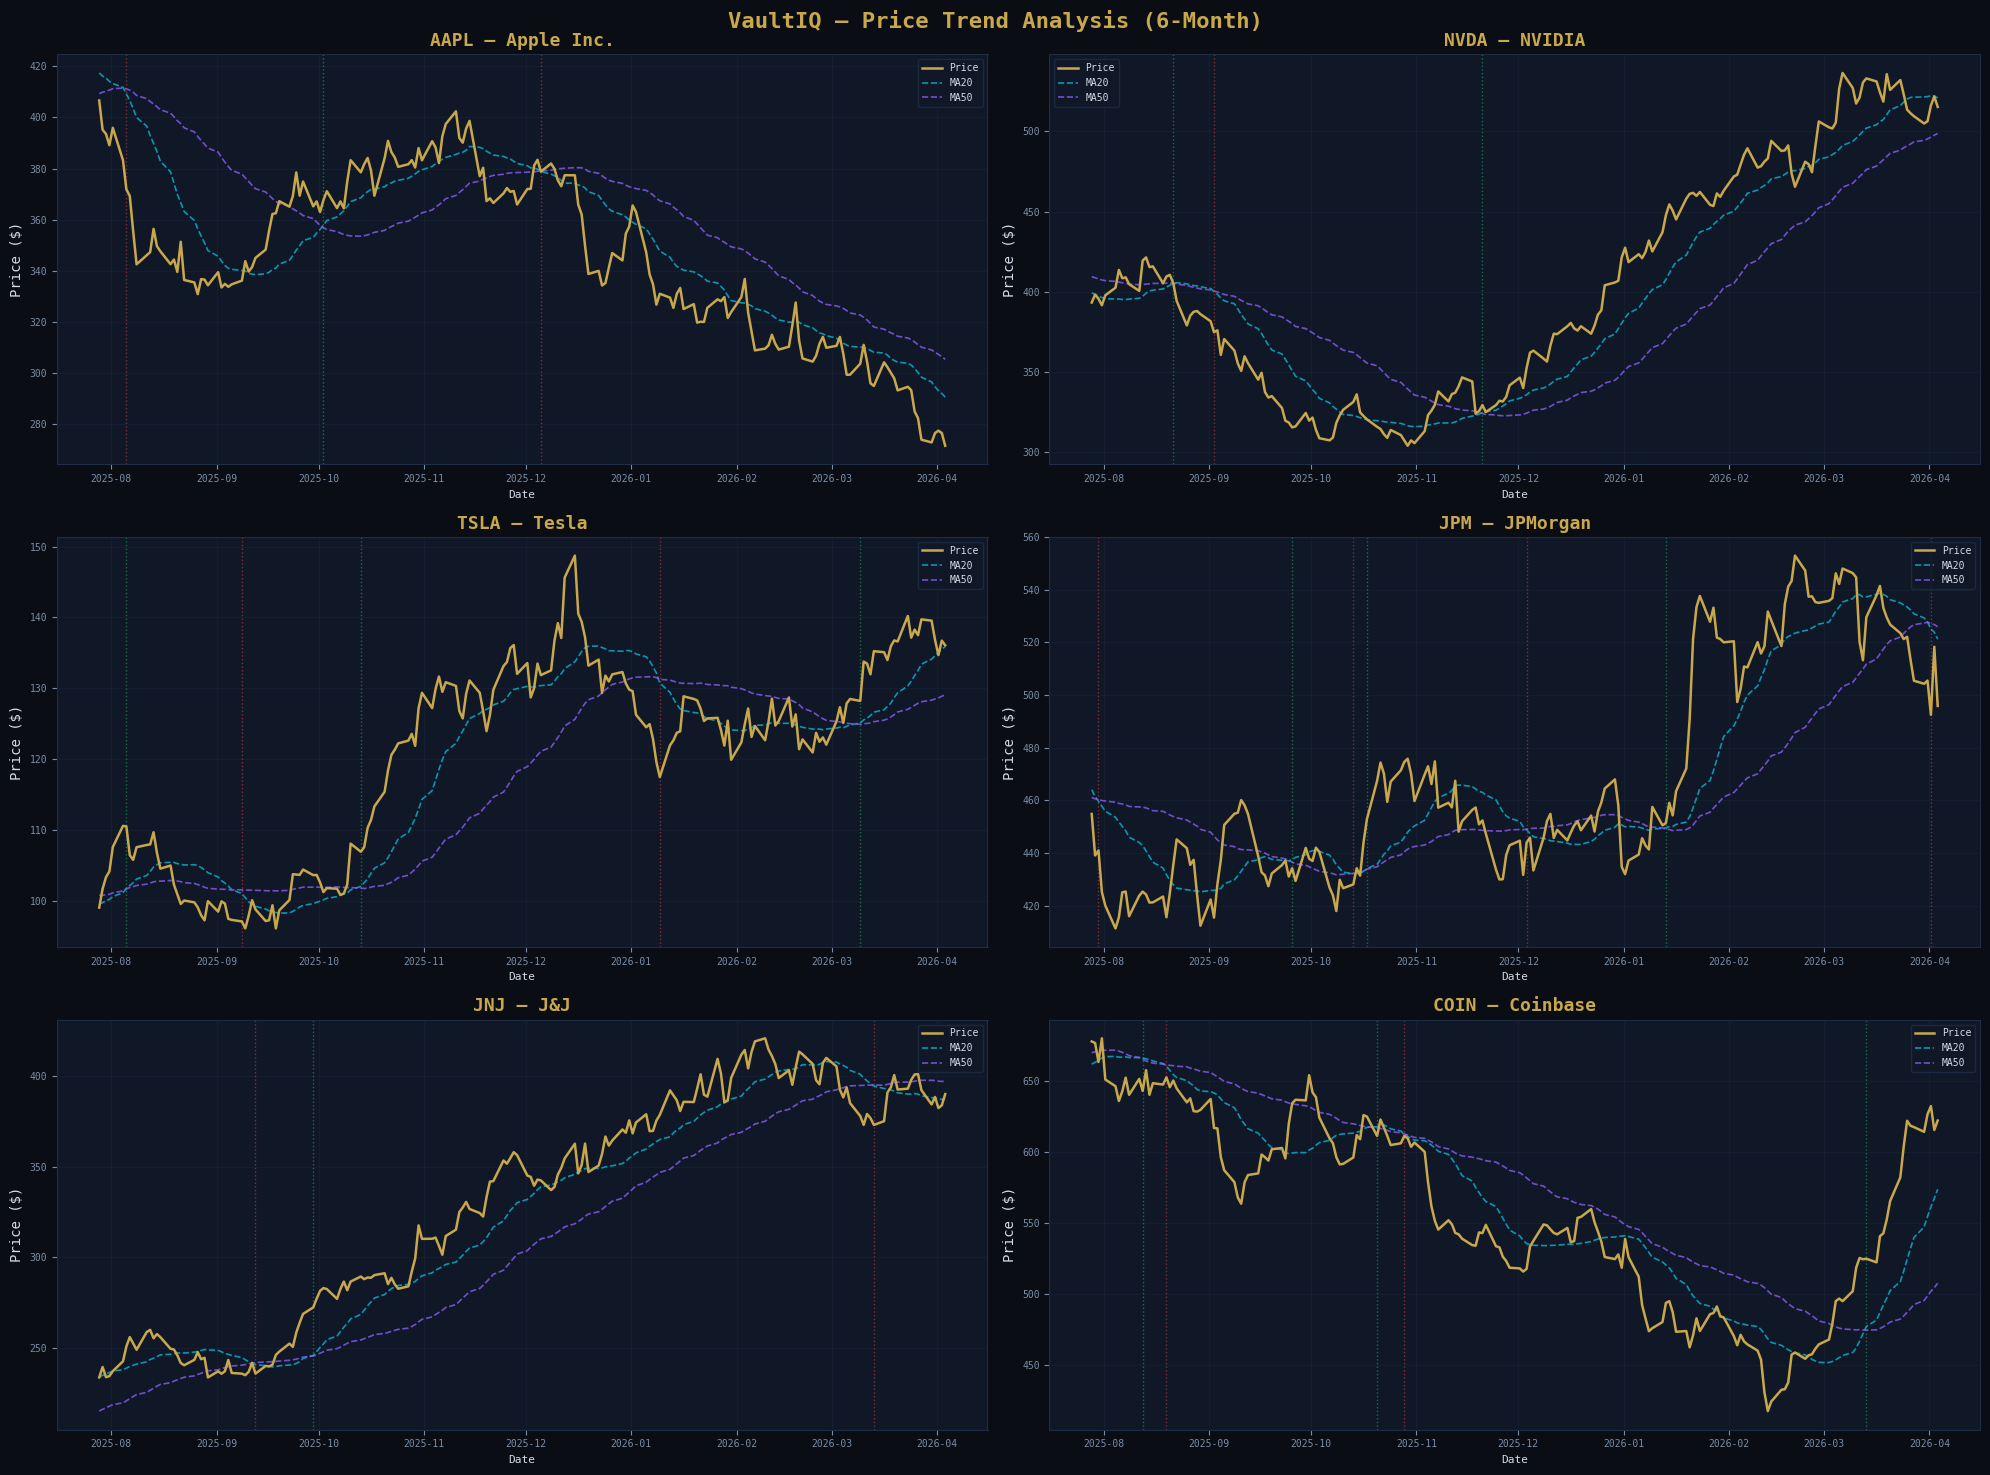

✅ Price trend charts generated


In [17]:
fig, axes = plt.subplots(3, 2, figsize=(20, 15), facecolor='#0a0d14')
fig.suptitle('VaultIQ — Price Trend Analysis (6-Month)', color=GOLD, fontsize=16, fontweight='bold')

featured = [('AAPL', 'Apple Inc.'), ('NVDA', 'NVIDIA'), ('TSLA', 'Tesla'),
            ('JPM', 'JPMorgan'), ('JNJ', 'J&J'), ('COIN', 'Coinbase')]

for ax, (sym, name) in zip(axes.flatten(), featured):
    if sym not in enriched:
        ax.set_visible(False); continue
    df = enriched[sym].tail(180)
    ax.plot(df.index, df['Close'], color=GOLD,   linewidth=1.8, label='Price', zorder=3)
    ax.plot(df.index, df['MA20'], color=CYAN,    linewidth=1.2, linestyle='--', label='MA20', alpha=0.8)
    ax.plot(df.index, df['MA50'], color=PURPLE,  linewidth=1.2, linestyle='--', label='MA50', alpha=0.8)
    # Highlight MA crossover regions
    ma20_arr = df['MA20'].values; ma50_arr = df['MA50'].values
    idx_arr  = df.index
    for i in range(1, len(ma20_arr)):
        if ma20_arr[i] > ma50_arr[i] and ma20_arr[i-1] <= ma50_arr[i-1]:
            ax.axvline(idx_arr[i], color=GREEN, linewidth=1, alpha=0.5, linestyle=':')
        elif ma20_arr[i] < ma50_arr[i] and ma20_arr[i-1] >= ma50_arr[i-1]:
            ax.axvline(idx_arr[i], color=RED, linewidth=1, alpha=0.5, linestyle=':')
    ax.set_title(f'{sym} — {name}')
    ax.set_xlabel('Date', fontsize=8)
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('eda_price_trends.png', dpi=150, bbox_inches='tight', facecolor='#0a0d14')
plt.show()
print("✅ Price trend charts generated")

## 10. EDA Summary & Key Findings

This section summarises all major insights discovered in this analysis.

In [18]:
print("=" * 70)
print("  VaultIQ EDA — KEY FINDINGS SUMMARY")
print("=" * 70)

print("\n1. RETURNS")
best_stock  = summary['Return_1Y'].idxmax()
worst_stock = summary['Return_1Y'].idxmin()
avg_return  = summary['Return_1Y'].mean()
print(f"   Best 1-year performer: {best_stock} ({summary.loc[best_stock,'Name']}) → {summary.loc[best_stock,'Return_1Y']:+.1f}%")
print(f"   Worst 1-year performer: {worst_stock} ({summary.loc[worst_stock,'Name']}) → {summary.loc[worst_stock,'Return_1Y']:+.1f}%")
print(f"   Average 1-year return across all stocks: {avg_return:+.1f}%")

print("\n2. VOLATILITY")
most_vol  = summary['Volatility'].idxmax()
least_vol = summary['Volatility'].idxmin()
print(f"   Most volatile: {most_vol} ({summary.loc[most_vol,'Name']}) → {summary.loc[most_vol,'Volatility']:.1f}% annualised vol")
print(f"   Most stable:   {least_vol} ({summary.loc[least_vol,'Name']}) → {summary.loc[least_vol,'Volatility']:.1f}% annualised vol")
sector_vol_rank = summary.groupby('Sector')['Volatility'].mean().sort_values(ascending=False)
print(f"   Most volatile sector: {sector_vol_rank.index[0]} ({sector_vol_rank.iloc[0]:.1f}%)")
print(f"   Least volatile sector: {sector_vol_rank.index[-1]} ({sector_vol_rank.iloc[-1]:.1f}%)")

print("\n3. RSI SIGNALS")
ob = (summary['RSI'] > 70).sum()
os = (summary['RSI'] < 30).sum()
print(f"   Overbought stocks (RSI > 70): {ob}")
print(f"   Oversold stocks (RSI < 30): {os}")
print(f"   Neutral stocks: {len(summary) - ob - os}")

print("\n4. DECISION SCORES")
for signal in ['BUY','HOLD','RISKY']:
    count = (summary['Signal'] == signal).sum()
    pct   = count / len(summary) * 100
    print(f"   {signal}: {count} stocks ({pct:.0f}%)")

print("\n5. CORRELATION")
print(f"   Computed correlation matrix: {len(corr_matrix)} x {len(corr_matrix)} stocks")
print(f"   Highly correlated pairs (r>0.85): {len(high_corr)}")

print("\n6. ANOMALIES")
total_anomalies = anom_df['Total'].sum()
print(f"   Total anomalous events detected: {total_anomalies}")
print(f"   Average per stock: {total_anomalies/len(anom_df):.1f}")

print("\n" + "=" * 70)
print("  ✅ EDA Complete — see 01_eda_analysis.ipynb in VaultIQ/notebooks/")
print("=" * 70)

  VaultIQ EDA — KEY FINDINGS SUMMARY

1. RETURNS
   Best 1-year performer: COP (ConocoPhillips) → +145.8%
   Worst 1-year performer: GOOGL (Alphabet Inc.) → -60.6%
   Average 1-year return across all stocks: +12.1%

2. VOLATILITY
   Most volatile: V (Visa Inc.) → 40.1% annualised vol
   Most stable:   ABBV (AbbVie Inc.) → 18.5% annualised vol
   Most volatile sector: Finance (30.2%)
   Least volatile sector: Health (25.4%)

3. RSI SIGNALS
   Overbought stocks (RSI > 70): 8
   Oversold stocks (RSI < 30): 5
   Neutral stocks: 27

4. DECISION SCORES
   BUY: 24 stocks (60%)
   HOLD: 16 stocks (40%)
   RISKY: 0 stocks (0%)

5. CORRELATION
   Computed correlation matrix: 40 x 40 stocks
   Highly correlated pairs (r>0.85): 0

6. ANOMALIES
   Total anomalous events detected: 178
   Average per stock: 4.5

  ✅ EDA Complete — see 01_eda_analysis.ipynb in VaultIQ/notebooks/
